<a href="https://colab.research.google.com/github/Ali13fffff/Ali13ffff/blob/main/heart_disease_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart (1).csv


#Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

#Load Data

In [ ]:
df=pd.read_csv("heart.csv")
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  1

#Cleaning Data

In [ ]:
print(df.isnull().sum())
print(df.duplicated().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
0


#Creating Engineered Features

In [ ]:
df["Cholesterol*Age"] = df["Cholesterol"] * df["Age"]
df["HR_per_Age"] = df["MaxHR"] / (220 - df["Age"])

#Feature Engineering

In [ ]:
Category_Col = df.select_dtypes(include="object").columns
df = pd.get_dummies(df, columns=Category_Col, drop_first=True, dtype=int)

#Data Splitting

In [ ]:
X = df.drop("HeartDisease", axis=1).copy()
y = df["HeartDisease"].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

### 🚀 Model Optimization Workflow
In this step, we implement a **Pipeline** that integrates SMOTE and Random Forest.
This ensures that data augmentation only happens during cross-validation,
preventing information leakage and providing more reliable evaluation metrics.

In [ ]:
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200, 300,400,500],
    'model__max_depth': [1,2,4,6,8,10,20],
    'model__min_samples_split': [2, 5, 10],
}

rf_cv = RandomizedSearchCV(
    pipeline, param_grid, cv=5, n_iter=25,
    scoring='f1', n_jobs=-1, random_state=42,
)

rf_cv.fit(X_train, y_train)

# 📊 Final Model Results

Best params: {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__max_depth': 8}
Best F1 Score: 0.8845963541719571

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184


--- Confusion Matrix ---


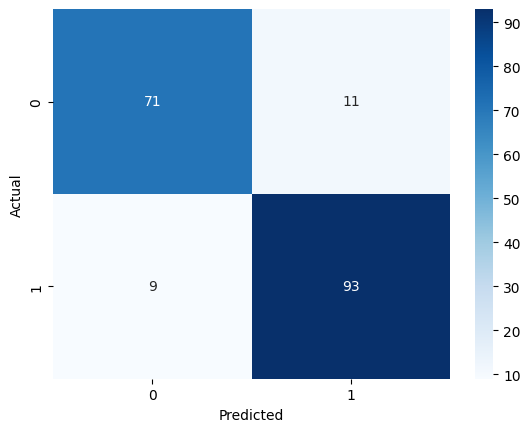

In [ ]:


best_model = rf_cv.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Best params: {rf_cv.best_params_}")
print(f"Best F1 Score: {rf_cv.best_score_}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#Feature Importance

Feature Importance:
              Feature  Importance
16        ST_Slope_Up    0.162257
15      ST_Slope_Flat    0.149146
14   ExerciseAngina_Y    0.114337
5             Oldpeak    0.095315
6     Cholesterol*Age    0.074680
7          HR_per_Age    0.072339
4               MaxHR    0.072146
2         Cholesterol    0.064763
0                 Age    0.046199
1           RestingBP    0.042945
8               Sex_M    0.035242
3           FastingBS    0.019343
9   ChestPainType_ATA    0.017569
10  ChestPainType_NAP    0.015086
12  RestingECG_Normal    0.007448
11   ChestPainType_TA    0.005804
13      RestingECG_ST    0.005380


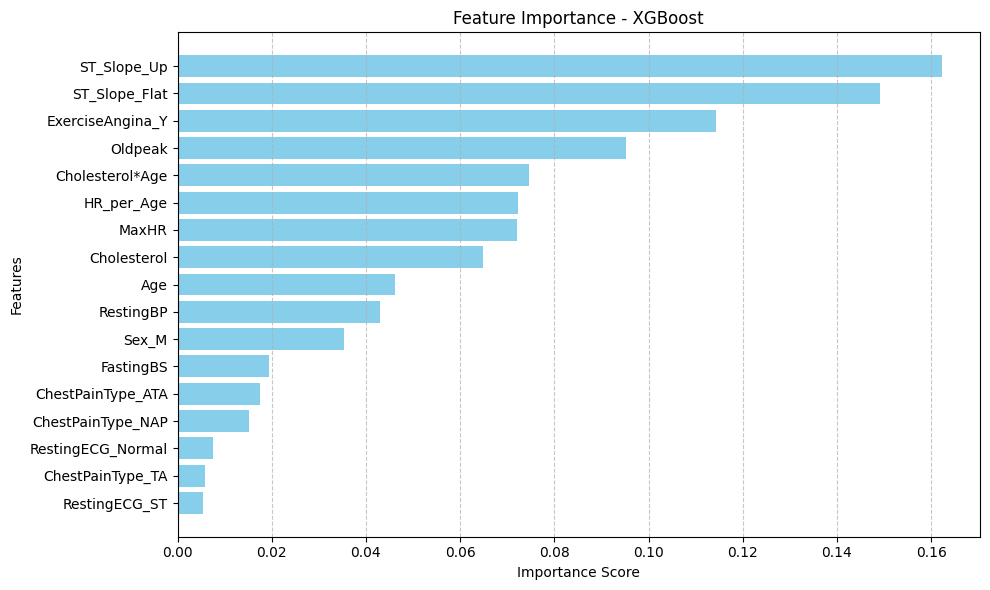

In [ ]:
importances = best_model.named_steps['model'].feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()